이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 IDMB 리뷰 감성 분류하기 튜토리얼입니다.  

링크 : https://wikidocs.net/24586  

# 1. IMDB 리뷰 데이터에 대한 이해

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print('훈련용 리뷰 개수 : {}'.format(len(X_train)))
print('테스트용 리뷰 개수 : {}'.format(len(X_test)))
num_classes = len(set(y_train))
print('카테고리 : {}'.format(num_classes))

훈련용 리뷰 개수 : 25000
테스트용 리뷰 개수 : 25000
카테고리 : 2


In [4]:
print(X_train[0])
print(y_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


리뷰의 최대 길이 : 2494
리뷰의 평균 길이 : 238.71364


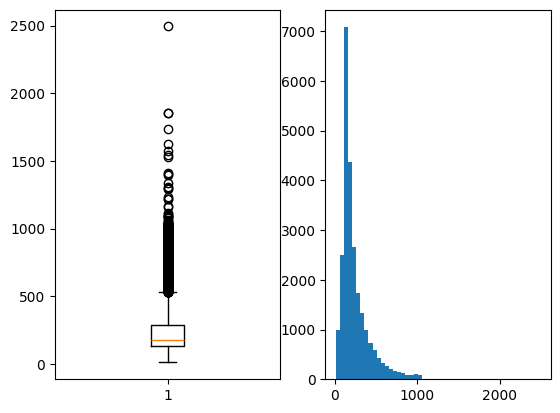

In [5]:
len_result = [len(s) for s in X_train]

print('리뷰의 최대 길이 : {}'.format(np.max(len_result)))
print('리뷰의 평균 길이 : {}'.format(np.mean(len_result)))

plt.subplot(1,2,1)
plt.boxplot(len_result)
plt.subplot(1,2,2)
plt.hist(len_result, bins=50)
plt.show()

In [6]:
unique_elements, counts_elements = np.unique(y_train, return_counts=True)
print("각 레이블에 대한 빈도수:")
print(np.asarray((unique_elements, counts_elements)))

각 레이블에 대한 빈도수:
[[    0     1]
 [12500 12500]]


In [7]:
word_to_index = imdb.get_word_index()
index_to_word={}
for key, value in word_to_index.items():
    index_to_word[value+3] = key

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print('빈도수 상위 1등 단어 : {}'.format(index_to_word[4]))

빈도수 상위 1등 단어 : the


In [9]:
print('빈도수 상위 3938등 단어 : {}'.format(index_to_word[3941]))

빈도수 상위 3938등 단어 : suited


In [10]:
for index, token in enumerate(("<pad>", "<sos>", "<unk>")):
  index_to_word[index]=token

print(' '.join([index_to_word[index] for index in X_train[0]]))

<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shoul

# 2. GRU로 IMDB 리뷰 감성 분류하기

| 모듈                                 | 주요 역할                     |
| ---------------------------------- | ------------------------- |
| `re`                               | 텍스트 정제 (특수문자, 불필요한 기호 제거) |
| `imdb`                             | IMDB 리뷰 데이터셋 로드           |
| `pad_sequences`                    | 문장 길이 통일                  |
| `Sequential`                       | 모델 구조 생성                  |
| `Embedding`                        | 단어 벡터화                    |
| `GRU`                              | 문맥 학습 (순환신경망)             |
| `Dense`                            | 출력층, 분류 계산                |
| `EarlyStopping`, `ModelCheckpoint` | 학습 중단 & 최적 모델 저장          |
| `load_model`                       | 저장된 모델 불러오기               |


In [11]:
# ============================================
# 🧠 IMDB 영화 리뷰 감성 분석 (GRU 모델) - 환경 설정
# ============================================

import re
# 🔹 정규표현식(regular expression)
#    → 텍스트 정제 과정에서 특수문자, 숫자, 영어 등을 제거할 때 사용

from tensorflow.keras.datasets import imdb
# 🔹 Keras 내장 IMDB 데이터셋 로드 도구
#    → (훈련/테스트 데이터, 라벨)을 자동으로 다운로드
#    → 각 리뷰는 단어를 숫자 인덱스로 변환한 시퀀스로 제공

from tensorflow.keras.preprocessing.sequence import pad_sequences
# 🔹 pad_sequences()
#    → 문장(시퀀스) 길이를 동일하게 맞추기 위한 패딩 도구

from tensorflow.keras.models import Sequential
# 🔹 Sequential()
#    → 층(layer)을 순차적으로 쌓는 가장 기본적인 모델 구조

from tensorflow.keras.layers import Dense, GRU, Embedding
# 🔹 Embedding : 단어를 벡터로 표현 (단어 ID → 의미 벡터)
# 🔹 GRU (Gated Recurrent Unit) : LSTM보다 간단하고 빠른 순환 신경망
# 🔹 Dense : 완전 연결층, 출력층 또는 중간층으로 사용

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# 🔹 EarlyStopping : 검증 성능이 더 이상 향상되지 않으면 학습 조기 종료
# 🔹 ModelCheckpoint : 학습 중 가장 좋은 모델(가장 높은 val_acc)을 자동 저장

from tensorflow.keras.models import load_model
# 🔹 load_model() : 저장된 모델 파일(.keras)을 불러와 재사용

- IMDB 데이터는 이미 정수 인코딩되어 있으므로 형태소 분석이나 토큰화 과정이 필요 없습니다.

- 단어 ID는 imdb.get_word_index()를 통해 실제 단어로 복원할 수 있습니다.

| 항목                  | 설명                                     |
| ------------------- | -------------------------------------- |
| **데이터셋**            | IMDB 영화 리뷰 (25,000개 훈련 / 25,000개 테스트)  |
| **입력(X)**           | 각 리뷰를 단어 ID의 시퀀스로 변환한 리스트              |
| **출력(y)**           | 리뷰 감성 레이블 → 0: 부정 / 1: 긍정              |
| **num_words=10000** | 등장 빈도가 높은 상위 10,000개 단어만 사용 (희귀 단어 제외) |


In [12]:
# ============================================
# 🎬 IMDB 영화 리뷰 데이터셋 로드
# ============================================

# vocab_size : 사용할 단어의 최대 개수 (상위 10,000개 단어만 사용)
vocab_size = 10000

# imdb.load_data() :
# - 이미 정수 인코딩이 완료된 IMDB 리뷰 데이터를 불러옴
# - (X_train, y_train): 훈련용 리뷰와 레이블
# - (X_test, y_test): 테스트용 리뷰와 레이블
# - num_words : 상위 10,000개의 단어만 단어 집합(vocabulary)에 포함

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

| 용어                   | 설명                                      |
| -------------------- | --------------------------------------- |
| **패딩 (Padding)**     | 문장의 길이를 동일하게 맞추기 위해 0을 채우는 과정           |
| **maxlen=500**       | 리뷰를 최대 500단어까지만 사용 (초과 시 잘림, 부족 시 0 추가) |
| **pre-padding**      | 문장 앞부분에 0을 채움 (기본 설정)                   |
| **truncating='pre'** | 긴 문장의 앞부분을 잘라내는 옵션 (기본 설정)              |


In [13]:
# ============================================
# 🧱 문장 길이 통일 (Padding)
# ============================================

# max_len : 각 리뷰의 최대 길이 설정 (단어 수 기준)
max_len = 500

# pad_sequences() :
#  - 각 리뷰를 동일한 길이로 맞추기 위해 0으로 채움
#  - 너무 긴 리뷰는 잘라내고, 짧은 리뷰는 앞쪽에 0을 추가 (기본 설정: pre-padding)
X_train = pad_sequences(X_train, maxlen=max_len)
X_test  = pad_sequences(X_test,  maxlen=max_len)

- IMDB 영화 리뷰 감성 분석을 위한 GRU 기반 신경망 모델 구성 단계입니다.
- 이전 LSTM 모델과 구조는 비슷하지만, GRU(Gated Recurrent Unit)는 계산 속도가 더 빠르고 파라미터가 적은 장점이 있습니다.

| 층 이름                  | 출력 형태                  | 주요 역할                      |
| --------------------- | ---------------------- | -------------------------- |
| **Embedding**         | (batch_size, 500, 100) | 단어 ID를 100차원 의미 벡터로 변환     |
| **GRU(128)**          | (batch_size, 128)      | 문맥/순서 학습, 기억-망각 게이트로 정보 전달 |
| **Dense(1, sigmoid)** | (batch_size, 1)        | 긍정(1) / 부정(0) 확률 예측        |

| 항목     | LSTM                 | GRU                     |
| ------ | -------------------- | ----------------------- |
| 구조     | 3개의 게이트 (입력, 망각, 출력) | 2개의 게이트 (업데이트, 리셋)      |
| 속도     | 다소 느림                | 빠름                      |
| 파라미터 수 | 많음                   | 적음                      |
| 성능     | 문맥이 복잡한 경우 유리        | 일반적인 시퀀스에서는 비슷하거나 더 효율적 |


In [14]:
# ============================================
# 🧠 GRU 기반 감성 분석 모델 구성
# ============================================

embedding_dim = 100    # 임베딩 벡터 차원 수
hidden_units = 128     # GRU 은닉층 노드 수 (기억 셀 개수)

model = Sequential()

# 1️⃣ Embedding 층
# - 입력: 단어의 정수 인덱스
# - 출력: 100차원 임베딩 벡터
# - 역할: 단어 ID → 의미 벡터로 변환
model.add(Embedding(vocab_size, embedding_dim))

# 2️⃣ GRU 층
# - 128개의 GRU 유닛으로 구성된 순환 신경망
# - 문장의 순서 정보와 문맥(Context)을 학습
# - LSTM보다 구조가 단순하고 계산 속도가 빠름
model.add(GRU(hidden_units))

# 3️⃣ Dense 층 (출력층)
# - 출력 노드 1개 → 긍정(1) / 부정(0) 이진 분류
# - sigmoid 활성화 함수로 확률 출력 (0~1)
model.add(Dense(1, activation='sigmoid'))

- GRU 모델 학습 중 자동으로 조기 종료(EarlyStopping) 와
최적 모델 자동 저장(ModelCheckpoint) 을 설정하는 부분입니다.
- 즉, 과적합(overfitting)을 방지하고,
가장 높은 정확도를 보인 모델만 저장하기 위한 “훈련 관리 콜백(callback)” 설정입니다.

| 콜백 이름               | 주요 역할                 | 기준 지표      | 조건                                   |
| ------------------- | --------------------- | ---------- | ------------------------------------ |
| **EarlyStopping**   | 손실이 더 이상 줄지 않으면 학습 중단 | `val_loss` | 개선이 4 epoch 이상 없을 때                  |
| **ModelCheckpoint** | 가장 높은 정확도의 모델 자동 저장   | `val_acc`  | 최고 성능 모델만 저장 (`save_best_only=True`) |



In [15]:
# ============================================
# 🧩 GRU 모델의 조기 종료 및 최적 모델 저장 설정
# ============================================

# 1️⃣ EarlyStopping
# - 검증 손실(val_loss)을 모니터링하여 더 이상 감소하지 않으면 학습 중단
# - 과적합(overfitting) 방지 목적
es = EarlyStopping(
    monitor='val_loss',   # 감시 대상: 검증 손실
    mode='min',           # 손실이 최소일 때를 최적 상태로 판단
    verbose=1,            # 중단 시 로그 메시지 출력
    patience=4            # 4 epoch 연속 개선되지 않으면 조기 종료
)

# 2️⃣ ModelCheckpoint
# - 검증 정확도(val_acc)가 가장 높은 모델만 저장
# - save_best_only=True로 설정하면, 매 epoch마다 덮어쓰지 않고 최고 성능 모델만 저장
mc = ModelCheckpoint(
    'GRU_model.h5',       # 저장 파일 이름
    monitor='val_acc',    # 감시 대상: 검증 정확도
    mode='max',           # 정확도가 높을수록 성능이 좋다고 판단
    verbose=1,            # 저장 시 로그 메시지 출력
    save_best_only=True   # 최고 성능 모델만 저장
)

- GRU 기반 감성분석 모델의 학습 설정 및 실행 단계입니다.
- 즉, compile()로 학습 방식(손실함수, 옵티마이저, 평가 지표) 를 정의하고,
fit()으로 실제 훈련을 수행합니다.

| 항목                   | 의미                       | 설명                                     |
| -------------------- | ------------------------ | -------------------------------------- |
| **optimizer**        | 학습률 조절 및 가중치 업데이트        | GRU/LSTM에는 `rmsprop`이 안정적              |
| **loss**             | 예측값과 실제값의 차이 계산          | `binary_crossentropy`는 확률 기반 이진 분류에 적합 |
| **metrics**          | 모델 성능 평가 지표              | 정확도(`acc`) 사용                          |
| **validation_split** | 훈련 데이터 중 일부를 검증용으로 자동 분리 | 모델의 일반화 성능 확인                          |
| **callbacks**        | 학습 중 자동 제어 기능            | `EarlyStopping`, `ModelCheckpoint`     |


In [16]:
# ============================================
# ⚙️ GRU 모델 컴파일 및 학습 수행 (약 1분)
# ============================================

# 1️⃣ 모델 컴파일 (compile)
# - 학습 방법, 손실함수, 평가 지표를 정의
model.compile(
    optimizer='rmsprop',            # 옵티마이저: RNN/GRU/LSTM 계열에 안정적인 RMSprop 사용
    loss='binary_crossentropy',     # 손실 함수: 이진 분류용 (0=부정, 1=긍정)
    metrics=['acc']                 # 평가 지표: 정확도(accuracy)
)

# 2️⃣ 모델 학습 (fit)
# - 훈련 데이터를 이용해 모델 학습
# - validation_split: 훈련 데이터의 20%를 검증용으로 사용
# - callbacks: 조기 종료(EarlyStopping) 및 최적 모델 저장(ModelCheckpoint) 적용
history = model.fit(
    X_train, y_train,
    epochs=15,                      # 전체 데이터를 15회 반복 학습
    batch_size=64,                  # 한 번에 64개 샘플씩 학습
    validation_split=0.2,           # 훈련 데이터의 20%를 검증 데이터로 사용
    callbacks=[es, mc],             # 콜백 함수 적용
    verbose=1                       # 학습 과정을 자세히 출력
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.6139 - loss: 0.6395
Epoch 1: val_acc improved from -inf to 0.80140, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - acc: 0.6142 - loss: 0.6393 - val_acc: 0.8014 - val_loss: 0.4280
Epoch 2/15
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.8221 - loss: 0.4075
Epoch 2: val_acc improved from 0.80140 to 0.81640, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0.8222 - loss: 0.4074 - val_acc: 0.8164 - val_loss: 0.3989
Epoch 3/15
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.8686 - loss: 0.3236
Epoch 3: val_acc improved from 0.81640 to 0.87340, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.8686 - loss: 0.3236 - val_acc: 0.8734 - val_loss: 0.3210
Epoch 4/15
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8900 - loss: 0.2746
Epoch 4: val_acc did not improve from 0.87340
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0.8900 - loss: 0.2746 - val_acc: 0.8654 - val_loss: 0.3177
Epoch 5/15
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9087 - loss: 0.2317
Epoch 5: val_acc improved from 0.87340 to 0.87900, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - acc: 0.9087 - loss: 0.2317 - val_acc: 0.8790 - val_loss: 0.2906
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9289 - loss: 0.1942
Epoch 6: val_acc improved from 0.87900 to 0.88120, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0.9289 - loss: 0.1942 - val_acc: 0.8812 - val_loss: 0.3101
Epoch 7/15
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9377 - loss: 0.1698
Epoch 7: val_acc did not improve from 0.88120
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - acc: 0.9377 - loss: 0.1698 - val_acc: 0.8706 - val_loss: 0.3306
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9542 - loss: 0.1356
Epoch 8: val_acc improved from 0.88120 to 0.88520, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0.9542 - loss: 0.1357 - val_acc: 0.8852 - val_loss: 0.2883
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9615 - loss: 0.1095
Epoch 9: val_acc did not improve from 0.88520
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0.9615 - loss: 0.1096 - val_acc: 0.8796 - val_loss: 0.3427
Epoch 10/15
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9687 - loss: 0.0949
Epoch 10: val_acc did not improve from 0.88520
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - acc: 0.9686 - loss: 0.0949 - val_acc: 0.8772 - val_loss: 0.3585
Epoch 11/15
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9801 - loss: 0.0636
Epoch 11: val_acc did not improve from 0.88520
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - acc: 0.9801 - loss: 0.0637 - val_acc: 0.8804 - val_loss: 0.3642
Epoch 12/15
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9845 - loss: 0.0497
Epoch 12: val_acc did not improve from 0.88520
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - acc: 0

- 학습 중 가장 좋은 성능을 보인 GRU 모델(GRU_model.h5)을 불러와,
테스트 데이터로 최종 성능을 평가하는 단계입니다.
- 즉, 모델의 일반화 능력(새로운 데이터에 대한 정확도) 을 확인하는 과정입니다.

| 항목                   | 설명                        |
| -------------------- | ------------------------- |
| **`load_model()`**   | 저장된 모델(`.h5`) 파일을 불러와 복원  |
| **`evaluate(X, y)`** | 입력 데이터(X)에 대한 손실값과 정확도 반환 |
| **`[1]`**            | 반환 리스트에서 두 번째 값(정확도)만 선택  |
| **`%.4f`**           | 소수점 아래 4자리까지 출력           |


In [17]:
# ============================================
# 💾 저장된 최적 GRU 모델 불러오기 및 평가
# ============================================

# 1️⃣ 최적 모델 불러오기
# - ModelCheckpoint로 저장된 'GRU_model.h5' 파일을 로드
# - 모델 구조, 가중치, optimizer 상태까지 그대로 복원됨
loaded_model = load_model('GRU_model.h5')

# 2️⃣ 테스트 데이터로 모델 성능 평가
# - evaluate()는 [손실(loss), 정확도(acc)]를 반환
# - [1] 인덱스를 사용하여 정확도만 추출해 출력
print("\n 테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8870 - loss: 0.3073

 테스트 정확도: 0.8874


- IMDB 데이터셋 기반 GRU 감성분석 모델에
새로운 영어 문장을 입력하면 긍정/부정 확률을 출력하는 핵심 예측 함수

| 단계       | 내용                           | 예시                                               |
| -------- | ---------------------------- | ------------------------------------------------ |
| ① 정제     | 특수문자 제거, 소문자 변환              | `"This movie is Great!" → "this movie is great"` |
| ② 정수 인코딩 | 단어를 숫자로 변환 (`word_to_index`) | `[14, 20, 45, 7, 315]`                           |
| ③ 패딩     | 길이를 `max_len=500`으로 맞춤       | `[0, 0, 0, ..., 14, 20, 45, 7, 315]`             |
| ④ 예측     | 모델이 긍정 확률 계산                 | `score = 0.91`                                   |
| ⑤ 출력     | `"91.00% 확률로 긍정 리뷰입니다."`     | ✅ 긍정 리뷰                                          |


In [18]:
# ============================================
# 💬 새로운 영어 문장 감성 예측 함수
# ============================================

def sentiment_predict(new_sentence):
    """
    새로운 영어 문장을 입력받아
    1️⃣ 텍스트 정제 → 2️⃣ 정수 인코딩 → 3️⃣ 패딩 → 4️⃣ 예측
    과정을 거쳐 긍정/부정 확률을 출력한다.
    """

    # 1️⃣ 텍스트 정제 (영문자와 숫자만 남기고 모두 제거)
    #    re.sub('[^0-9a-zA-Z ]', '', ...) : 특수문자 제거
    #    lower() : 모두 소문자로 변환
    new_sentence = re.sub('[^0-9a-zA-Z ]', '', new_sentence).lower()

    # 2️⃣ 정수 인코딩
    #    - IMDB 데이터셋은 이미 단어별 정수 인덱스를 갖고 있음
    #    - 단어 사전(word_to_index)을 이용해 각 단어를 숫자로 변환
    #    - 사전에 없는 단어 또는 10,000등 이후 단어는 <unk>(2)로 처리
    encoded = []
    for word in new_sentence.split():
        try:
            if word_to_index[word] <= 10000:
                encoded.append(word_to_index[word] + 3)  # 실제 IMDB offset 반영
            else:
                encoded.append(2)  # <unk> 토큰
        except KeyError:
            encoded.append(2)  # <unk> 토큰

    # 3️⃣ 패딩 (길이를 max_len으로 통일)
    pad_sequence = pad_sequences([encoded], maxlen=max_len)

    # 4️⃣ 예측 (긍정 확률 계산)
    score = float(loaded_model.predict(pad_sequence))

    # 5️⃣ 결과 출력
    if score > 0.5:
        print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
    else:
        print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [19]:
test_input = "This movie was just way too overrated. The fighting was not professional and in slow motion. I was expecting more from a 200 million budget movie. The little sister of T.Challa was just trying too hard to be funny. The story was really dumb as well. Don't watch this movie if you are going because others say its great unless you are a Black Panther fan or Marvels fan."

sentiment_predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
98.81% 확률로 부정 리뷰입니다.


/tmp/ipython-input-748936229.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_sequence))


In [20]:
test_input = " I was lucky enough to be included in the group to see the advanced screening in Melbourne on the 15th of April, 2012. And, firstly, I need to say a big thank-you to Disney and Marvel Studios. \
Now, the film... how can I even begin to explain how I feel about this film? It is, as the title of this review says a 'comic book triumph'. I went into the film with very, very high expectations and I was not disappointed. \
Seeing Joss Whedon's direction and envisioning of the film come to life on the big screen is perfect. The script is amazingly detailed and laced with sharp wit a humor. The special effects are literally mind-blowing and the action scenes are both hard-hitting and beautifully choreographed."

sentiment_predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
98.95% 확률로 긍정 리뷰입니다.


/tmp/ipython-input-748936229.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_sequence))
